# Housing Unit Allocation with Person Record File Full Workflow

## Overview
This code works with the National Structures Inventory to run the housing unit allocation (HUA) and the person record file (PREC) workflow.
The HUA process is generalizable to any county in the United States. The HUA process will work for any file that has locations of structures and some basic information about the buildings.
The process is designed to work with [IN-CORE](https://incore.ncsa.illinois.edu/), a community resilience modeling environment.
Using IN-CORE requires an account and access to the IN-CORE Dataservice.

Functions are provided to obtain and clean data required for the version 2 Housing Unit Allocation. 

## Required Inputs
Program requires the following inputs:
If using the National Structures Inventory there are no required inputs.
    
## Output Description
The output of this workflow is a CSV file with the housing unit inventory allocated to a building inventory using the housing unit allocation model.

The output CSV is designed to be used in the Interdependent Networked Community Resilience Modeling Environment (IN-CORE).

IN-CORE is an open source python package that can be used to model the resilience of a community. To download IN-CORE, see:

https://incore.ncsa.illinois.edu/


## Instructions
Users can run the workflow by executing each block of code in the notebook.

## Description of Program
- program:    ncoda_07fv3_HUA_PREC_NSI
- task:       Start with NSI building inventory, run housing unit allocation algorithm, and then run person record file algorithm
- See github commits for description of program updates
- Current Version: v3 - 
- 2024-02-20 - Combine code from 07c, 07d, and 07e into one notebook
- 2024-05-22 - removed the drop down menu, did not work consistently
- 2025-02-21 - Test with 2020 HUI
- 2025-03-07 - Update to version 2 to differentiate running 2010 and 2020
- 2025-03-27 - V3 Solved issue for states starting with 0 FIPS code - major modification to code
- project:    Interdependent Networked Community Resilience Modeling Environment (IN-CORE), Subtask 5.2 - Social Institutions
- funding:	  NIST Financial Assistance Award Numbers: 70NANB15H044 and 70NANB20H008
- funding:	  Southeast Texas Urban Integrated Field Lab Department of Energy DE-SC0023216 
- author:     Nathanael Rosenheim

## Required Citations:
Rosenheim, Nathanael, Roberto Guidotti, Paolo Gardoni & Walter Gillis Peacock. (2021). Integration of detailed household and housing unit characteristic data with critical infrastructure for post-hazard resilience modeling. _Sustainable and Resilient Infrastructure_. 6(6), 385-401. https://doi.org/10.1080/23789689.2019.1681821

Rosenheim, Nathanael (2021) “Detailed Household and Housing Unit Characteristics: Data and Replication Code.” _DesignSafe-CI_. 
https://doi.org/10.17603/ds2-jwf6-s535.

In [1]:
# To reload submodules need to use this magic command to set autoreload on
%load_ext autoreload
%autoreload 2
from pyncoda.ncoda_00g_community_options import *
from IPython.display import display

### How to set up the Community Dictionary
Please review the python code in the file pyncoda/ncoda_00g_community_options.py

In this file you will find a collection of data dictionaries with various ways to setup the inputs for the Housing Unit Allocation process. 

The basic dictionary includes the name of the community, the county FIPS code, your input building inventory file, and key variables in the building inventory file.

In [2]:
# select a community from this list
# if your community is not in this list, add it to the file ncoda_00g_community_options.py
list_community_options(communities_dictionary)

['Lumberton, NC: IN-CORE Building inventory for Robeson County, NC',
 'Galveston, TX: IN-CORE Building inventory for Galveston County, TX',
 'Galveston, TX: NSI Building inventory for Galveston County, TX',
 'Galveston, TX: IN-CORE Building inventory for Galveston Island, TX',
 'Mayfield, KY: NSI Building inventory for Graves County, KY',
 'Beaumont, TX: NSI Building inventory for Jefferson County, TX',
 'Beaumont, TX: Safayet Building inventory for Jefferson County, TX',
 'Pentwater, MI: NSI Building inventory for Oceana County, MI',
 'Seaside, OR: NSI Building inventory for Clatsop County, OR',
 'Lane County, OR: NSI Building inventory for Lane County, OR',
 'Benton County, OR: NSI Building inventory for Benton County, OR',
 'Southeast Texas Urban Integrated Field Lab: NSI Building inventory for Southeast Texas',
 'Southeast Texas Urban Integrated Field Lab (12 neighbor counties): NSI Building inventory for Southeast Texas',
 'Brazos County, TX: NSI Building inventory for Brazos Coun

In [3]:
community_id_by_name = 'Adams Co, CO: NSI Building inventory for Adams County, CO, 2010'

In [4]:
community_id, focalplace, countyname, countyfips = get_community_id_by_name(community_id_by_name)
communities = {community_id : communities_dictionary[community_id]}

Selected community ID: Adams_County_CO_NSI
Adams Co, CO is in COLORADO
Focal place: Adams
Adams Co, CO is in Adams County, CO with FIPS code 08001
Use IN-CORE: False


## Setup Python Environment

In [5]:
import pandas as pd
import geopandas as gpd # For reading in shapefiles
import numpy as np
import sys # For displaying package versions
import os # For managing directories and file paths if drive is mounted
import scooby # Reports Python environment

import contextily as cx # For adding basemap tiles to plot
import matplotlib.pyplot as plt # For plotting and making graphs

In [6]:
# open, read, and execute python program with reusable commands
from pyncoda.ncoda_00d_cleanvarsutils import *
from pyncoda.ncoda_04c_poptableresults import *
from pyncoda.ncoda_07i_process_communities import process_community_workflow

In [7]:
# Generate report of Python environment
base_packages = ['pandas','ipyleaflet','seaborn','contextily']
incore_packages = ['pyincore','pyincore_viz']
check_packages = base_packages + incore_packages
print(scooby.Report(additional=check_packages))


--------------------------------------------------------------------------------
  Date: Thu Mar 27 16:01:49 2025 Central Daylight Time

                OS : Windows (10 10.0.22631 SP0 Multiprocessor Free)
            CPU(s) : 16
           Machine : AMD64
      Architecture : 64bit
               RAM : 31.7 GiB
       Environment : Jupyter

  Python 3.10.14 | packaged by Anaconda, Inc. | (main, May  6 2024, 19:44:50)
  [MSC v.1916 64 bit (AMD64)]

            pandas : 2.2.2
        ipyleaflet : Module not found
           seaborn : 0.13.2
        contextily : 1.6.0
          pyincore : Module not found
      pyincore_viz : Module not found
             numpy : 1.26.4
             scipy : 1.13.1
           IPython : 8.25.0
        matplotlib : 3.8.4
            scooby : 0.10.0

  Intel(R) oneAPI Math Kernel Library Version 2023.1-Product Build 20230303
  for Intel(R) 64 architecture applications
--------------------------------------------------------------------------------


In [8]:
# Check working directory - good practice for relative path access
os.getcwd()

'c:\\Users\\nathanael99\\MyProjects\\GitHub\\intersect-community-data'

## Run Housing Unit Allocation
The following code will produce the following outputs:
1. Housing Unit Inventory
2. Address Point Inventory
3. Housing Unit Allocation

In [9]:
basevintage_options = ['2010','2020']

Creating folder OutputData/Adams_County_CO_NSI to store output.
Creating folder OutputData/Adams_County_CO_NSI/00_logfiles
     logfiles Folder purpose: Store text files with log of workflow.
Creating folder OutputData/Adams_County_CO_NSI/01_CommunitySourceData
     CommunitySourceData Folder purpose: Source source data files. Helps with software development and replication.
Creating folder OutputData/Adams_County_CO_NSI/02_TidyCommunitySourceData
     TidyCommunitySourceData Folder purpose: Cleaned source data and inputs for base inventory.
Creating folder OutputData/Adams_County_CO_NSI/03_BaseInventory
     BaseInventory Folder purpose: Initial inventories before random merge. Use as inputs to uncertainty propagation.
Creating folder OutputData/Adams_County_CO_NSI/04_RandomMerge
     RandomMerge Folder purpose: Results of random merge with flag columns.
Creating folder OutputData/Adams_County_CO_NSI/05_Verify
     Verify Folder purpose: Results to compare inventories with source data

c:\Users\nathanael99\MyProjects\GitHub\intersect-community-data\pyncoda\CommunitySourceData\api_census_gov\acg_02a_add_categorical_char.py:762: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  set_flag_df.loc[conditions, self.flaggeo_var] = .5


Longest tract : 061200
tract Expected Length 6 Available Length 6
tract is type object
after update tract is type object
Longest Tract2010 : 08001061200
Tract2010 Expected Length 11 Available Length 11
Geolevels available ['state', 'county', 'tract']
Geolvarids available ['Tract2010']
Adding County2010 expected length 5
Dataframe has Tract 2010 for new geovar County2010
Confirming County2010 has expected length.
Longest County2010 : 08001
County2010 Expected Length 5 Available Length 5
Checking primary key name uniqueidB19101
Primary key variable uniqueidB19101 is unique.
Primary key uniqueidB19101 has no missing values
['uniqueidB19101', 'County2010', 'Tract2010', 'index', 'GEO_ID', 'state', 'county', 'tract', 'race', 'hispan', 'incomegroup', 'hu_counter', 'family', 'family_flagsetrm', 'family_Tract2010_flagsetrm']
Initializing geovar flag set variable for family at geolevel County2010
New flag: family_County2010_flagsetrm
Observations without primary flag set 0
Observations without g

c:\Users\nathanael99\MyProjects\GitHub\intersect-community-data\pyncoda\CommunitySourceData\api_census_gov\acg_02a_add_categorical_char.py:762: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  set_flag_df.loc[conditions, self.flaggeo_var] = .5


0 observations do not have required variable County2010
9425 observations do not have required variable hispan
9425 observations do not have required variable family
9425 observations do not have required variable hispan
9425 observations do not have required variable race
Setting 0 flags for observations without required variable County2010
Setting 9425 flags for observations without required variable hispan
Setting 9425 flags for observations without required variable family
Setting 9425 flags for observations without required variable race
0 observations do not have required variable County2010
9425 observations do not have required variable race
9425 observations do not have required variable family
9425 observations do not have required variable hispan
9425 observations do not have required variable race
Setting 0 flags for observations without required variable County2010
Setting 9425 flags for observations without required variable hispan
Setting 9425 flags for observations with

...

Longest tract : 061200
tract Expected Length 6 Available Length 6
tract is type object
after update tract is type object
Longest Tract2020 : 08001061200
Tract2020 Expected Length 11 Available Length 11
Geolevels available ['state', 'county', 'tract']
Geolvarids available ['County2020', 'Tract2020']
Adding County2020 expected length 5
Dataframe has Tract 2020 for new geovar County2020
Confirming County2020 has expected length.
Longest County2020 : 08001
County2020 Expected Length 5 Available Length 5
Checking primary key name uniqueidB19001
Primary key variable uniqueidB19001 is unique.
Primary key uniqueidB19001 has no missing values
['uniqueidB19001', 'County2020', 'Tract2020', 'index', 'GEO_ID', 'state', 'county', 'tract', 'race', 'hispan', 'hu_counter', 'family', 'incomegroup', 'family_flagsetrm', 'family_Tract2020_flagsetrm', 'family_County2020_flagsetrm', 'incomegroup_flagsetrm', 'incomegroup_Tract2020_flagsetrm']
Initializing geovar flag set variable for incomegroup at geolevel C

c:\Users\nathanael99\MyProjects\GitHub\intersect-community-data\pyncoda\CommunitySourceData\api_census_gov\acg_02a_add_categorical_char.py:785: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '7.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  set_flag_df.loc[conditions, self.flaggeo_var] = self.round+.5
c:\Users\nathanael99\MyProjects\GitHub\intersect-community-data\pyncoda\CommunitySourceData\api_census_gov\acg_02a_add_categorical_char.py:785: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '8.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  set_flag_df.loc[conditions, self.flaggeo_var] = self.round+.5


Merge found extra incomegroup  observations: 32222

***************************************
    Set Flags after Merge
***************************************

['huid', 'County2020', 'race', 'family', 'random_mergeorder', 'uniqueidB19001', 'incomegroup', 'check_merge', 'family_flagsetrm', 'family_Tract2020_flagsetrm', 'family_County2020_flagsetrm', 'incomegroup_flagsetrm', 'incomegroup_Tract2020_flagsetrm', 'incomegroup_County2020_flagsetrm']
Observations without primary flag set 32392
Observations without geovar flag set 32392
After updated observations without geovar flag set 32392
Round = 8
Setting 170 flags for observations set by random merge using both primary and secondary data.
Setting 0 flags for observations set by random merge using only primary data.
0 observations do not have required variable County2020
0 observations do not have required variable family
0 observations do not have required variable race
Setting 0 flags for observations without required variable County2020


c:\Users\nathanael99\MyProjects\GitHub\intersect-community-data\pyncoda\ncoda_07d_run_hua_workflow.py:171: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[1.5 1.5 1.5 ... 1.5 1.5 1.5]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  addptv2_df.loc[condition1 & condition2 & condition3,'ownershp1'] \


Round 1

***************************************
***************************************

Performing random merge at geography level: Block

***************************************
***************************************


***************************************
***************************************

Attempt to merge hui on all common group vars.

***************************************
***************************************

Running random merge by ['Block2020', 'huicounter3', 'ownershp1']

***************************************
    Setting up  primary data with primary key and flags
***************************************

Adding Block2020 to column list
Longest Block2020 : 080010612002034
Block2020 Expected Length 15 Available Length 15
Geolevels available []
Geolvarids available ['Block2020']
Adding Block2020 expected length 15
Dataframe has Block 2020 for new geovar Block2020
Confirming Block2020 has expected length.
Longest Block2020 : 080010612002034
Block2020 Expected Lengt

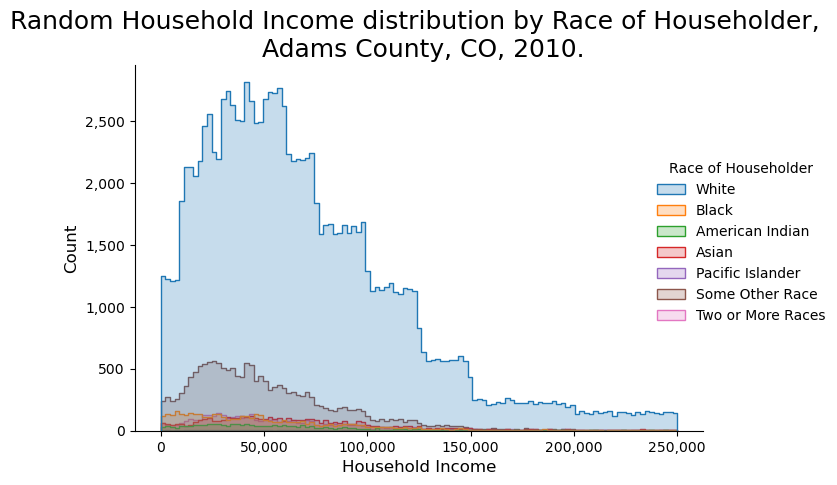

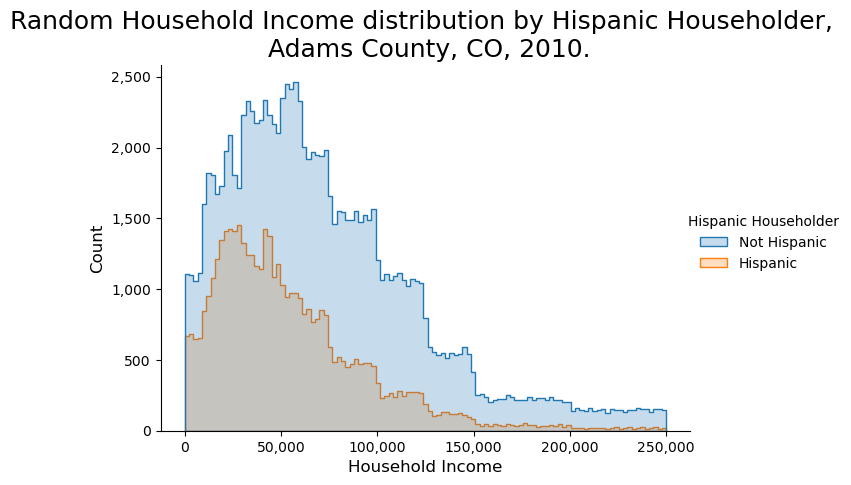

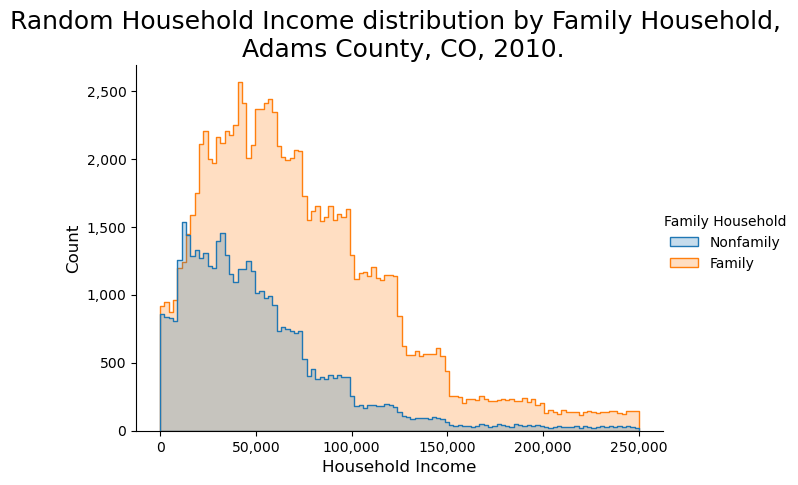

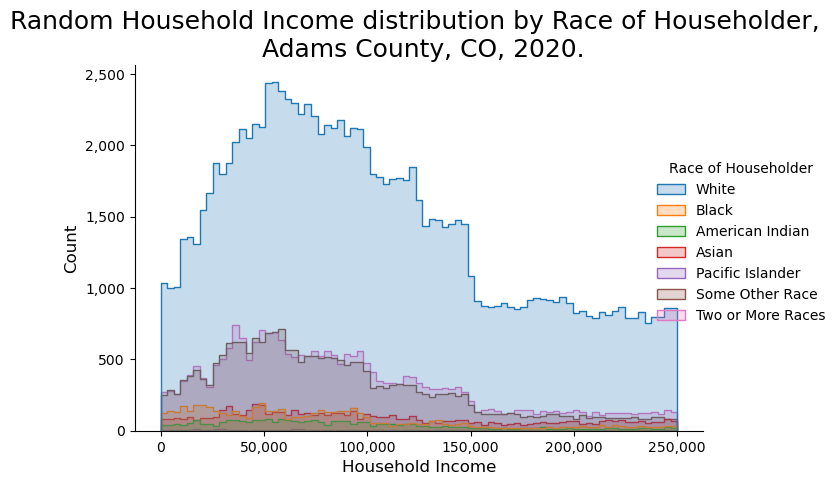

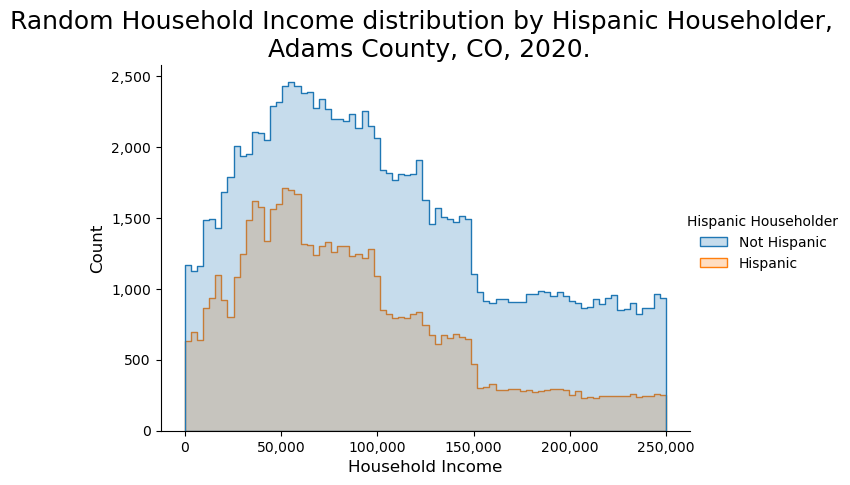

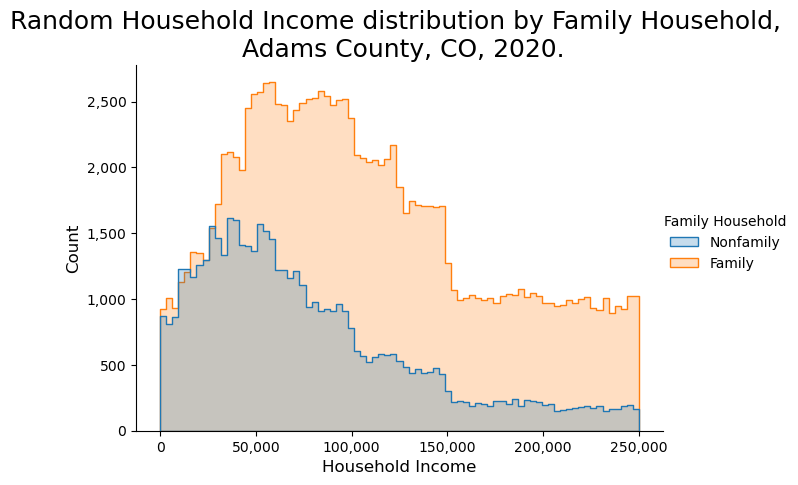

In [10]:
hua_hui_gdf_dict = {}
for basevintage in basevintage_options:
    workflow = process_community_workflow(
                communities,
                seed = 9876,
                version = '2.1.0',
                version_text = 'v2-1-0',
                basevintage = basevintage,
                outputfolder ="OutputData",
                outputfolders = {},
                savefiles = True)
    hua_hui_gdf_dict[basevintage] = workflow.process_communities()

## Run Person Record File

In [11]:
'''
version = '3.0.0'
version_text = 'v3-0-0'

# open, read, and execute python program with reusable commands
from pyncoda.ncoda_07e_generate_prec import generate_prec_functions

# Save Outputfolder - due to long folder name paths output saved to folder with shorter name
# files from this program will be saved with the program name - 
# this helps to follow the overall workflow
outputfolder = "OutputData"
# Make directory to save output
if not os.path.exists(outputfolder):
    os.mkdir(outputfolder)

# Set random seed for reproducibility
seed = 1000
basevintage = 2020

generate_prec_df = generate_prec_functions(
                    communities =   communities,
                    seed =          seed,
                    version =       version,
                    version_text=   version_text,
                    basevintage=    basevintage,
                    outputfolder=   outputfolder
                    )

prec_df = generate_prec_df.generate_prec_v300()
'''

'\nversion = \'3.0.0\'\nversion_text = \'v3-0-0\'\n\n# open, read, and execute python program with reusable commands\nfrom pyncoda.ncoda_07e_generate_prec import generate_prec_functions\n\n# Save Outputfolder - due to long folder name paths output saved to folder with shorter name\n# files from this program will be saved with the program name - \n# this helps to follow the overall workflow\noutputfolder = "OutputData"\n# Make directory to save output\nif not os.path.exists(outputfolder):\n    os.mkdir(outputfolder)\n\n# Set random seed for reproducibility\nseed = 1000\nbasevintage = 2020\n\ngenerate_prec_df = generate_prec_functions(\n                    communities =   communities,\n                    seed =          seed,\n                    version =       version,\n                    version_text=   version_text,\n                    basevintage=    basevintage,\n                    outputfolder=   outputfolder\n                    )\n\nprec_df = generate_prec_df.generate_prec_v

## Explore and Validate Housing Unit Allocation


### Look at population characteristics and compare to US Census

In [56]:
where = communities[community_id]['community_name']
print(where, focalplace, countyname, countyfips)

Adams Co, CO Brighton Adams County, CO 08001


In [50]:
PopResultsTable.pop_results_table(
                  input_df = hua_hui_gdf_dict['2010'], 
                  who = "Total Population by Households", 
                  what = "by Race, Ethnicity",
                  where = countyname,
                  when = '2010',
                  row_index = "Race Ethnicity",
                  col_index = 'Tenure Status')

Tenure Status,1 Owner Occupied (%),2 Renter Occupied (%),Total Population by Households (%)
Race Ethnicity,,,
"1 White alone, Not Hispanic","180,740 (63.0%)","60,422 (41.4%)","241,162 (55.7%)"
"2 Black alone, Not Hispanic","5,220 (1.8%)","5,739 (3.9%)","10,959 (2.5%)"
"3 American Indian and Alaska Native alone, Not Hispanic","1,115 (0.4%)",961 (0.7%),"2,076 (0.5%)"
"4 Asian alone, Not Hispanic","10,862 (3.8%)","3,383 (2.3%)","14,245 (3.3%)"
"5 Other Race, Not Hispanic","3,057 (1.1%)","1,551 (1.1%)","4,608 (1.1%)"
"6 Any Race, Hispanic","86,008 (30.0%)","74,061 (50.7%)","160,069 (37.0%)"
Total,"287,002 (100.0%)","146,117 (100.0%)","433,119 (100.0%)"


In [51]:
PopResultsTable.pop_results_table(
                  input_df = hua_hui_gdf_dict['2020'], 
                  who = "Total Population by Households", 
                  what = "by Race, Ethnicity",
                  where = countyname,
                  when = '2020',
                  row_index = "Race Ethnicity",
                  col_index = 'Tenure Status')

Tenure Status,1 Owner Occupied (%),2 Renter Occupied (%),Total Population by Households (%)
Race Ethnicity,,,
"1 White alone, Not Hispanic","189,793 (54.7%)","59,845 (37.2%)","249,638 (49.2%)"
"2 Black alone, Not Hispanic","6,613 (1.9%)","8,245 (5.1%)","14,858 (2.9%)"
"3 American Indian and Alaska Native alone, Not Hispanic","1,360 (0.4%)","1,205 (0.7%)","2,565 (0.5%)"
"4 Asian alone, Not Hispanic","15,974 (4.6%)","5,591 (3.5%)","21,565 (4.2%)"
"5 Other Race, Not Hispanic","10,635 (3.1%)","5,303 (3.3%)","15,938 (3.1%)"
"6 Any Race, Hispanic","122,411 (35.3%)","80,575 (50.1%)","202,986 (40.0%)"
Total,"346,786 (100.0%)","160,764 (100.0%)","507,550 (100.0%)"


In [52]:
PopResultsTable.pop_results_table(
                  input_df = hua_hui_gdf_dict['2010'], 
                  who = "Total Population by Households", 
                  what = "by Race, Ethnicity",
                  where = countyname,
                  when = '2010',
                  row_index = "Race Ethnicity",
                  col_index = 'Hispanic')

Hispanic,0. Not Hispanic or Latino (%),1. Hispanic or Latino (%),Total Population by Households (%)
Race Ethnicity,,,
"1 White alone, Not Hispanic","241,162 (88.3%)",nan (nan%),"241,162 (55.7%)"
"2 Black alone, Not Hispanic","10,959 (4.0%)",nan (nan%),"10,959 (2.5%)"
"3 American Indian and Alaska Native alone, Not Hispanic","2,076 (0.8%)",nan (nan%),"2,076 (0.5%)"
"4 Asian alone, Not Hispanic","14,245 (5.2%)",nan (nan%),"14,245 (3.3%)"
"5 Other Race, Not Hispanic","4,608 (1.7%)",nan (nan%),"4,608 (1.1%)"
"6 Any Race, Hispanic",nan (nan%),"160,069 (100.0%)","160,069 (37.0%)"
Total,"273,050 (100.0%)","160,069 (100.0%)","433,119 (100.0%)"


In [53]:
PopResultsTable.pop_results_table(
                  input_df = hua_hui_gdf_dict['2020'], 
                  who = "Total Population by Households", 
                  what = "by Race, Ethnicity",
                  where = countyname,
                  when = '2020',
                  row_index = "Race Ethnicity",
                  col_index = 'Hispanic')

Hispanic,0. Not Hispanic or Latino (%),1. Hispanic or Latino (%),Total Population by Households (%)
Race Ethnicity,,,
"1 White alone, Not Hispanic","249,638 (82.0%)",nan (nan%),"249,638 (49.2%)"
"2 Black alone, Not Hispanic","14,858 (4.9%)",nan (nan%),"14,858 (2.9%)"
"3 American Indian and Alaska Native alone, Not Hispanic","2,565 (0.8%)",nan (nan%),"2,565 (0.5%)"
"4 Asian alone, Not Hispanic","21,565 (7.1%)",nan (nan%),"21,565 (4.2%)"
"5 Other Race, Not Hispanic","15,938 (5.2%)",nan (nan%),"15,938 (3.1%)"
"6 Any Race, Hispanic",nan (nan%),"202,986 (100.0%)","202,986 (40.0%)"
Total,"304,564 (100.0%)","202,986 (100.0%)","507,550 (100.0%)"


In [55]:
PopResultsTable.pop_results_table(hua_hui_gdf_dict['2010'], 
                   who = "Median Household Income", 
                  what = "by Race, Ethnicity",
                  where = where,
                  when = '2010',
                  row_index = "Race Ethnicity",
                  col_index = 'Tenure Status')

Tenure Status,1 Owner Occupied,2 Renter Occupied,Median Household Income
Race Ethnicity,,,
"1 White alone, Not Hispanic","$68,106","$52,300","$63,349"
"2 Black alone, Not Hispanic","$57,446","$34,342","$44,493"
"3 American Indian and Alaska Native alone, Not Hispanic","$59,811","$53,641","$56,636"
"4 Asian alone, Not Hispanic","$65,598","$49,078","$61,012"
"5 Other Race, Not Hispanic","$64,088","$42,788","$56,970"
"6 Any Race, Hispanic","$51,238","$40,458","$45,519"
Total,"$63,346","$45,783","$57,061"


In [54]:
PopResultsTable.pop_results_table(hua_hui_gdf_dict['2020'], 
                   who = "Median Household Income", 
                  what = "by Race, Ethnicity",
                  where = where,
                  when = '2020',
                  row_index = "Race Ethnicity",
                  col_index = 'Tenure Status')

Tenure Status,1 Owner Occupied,2 Renter Occupied,Median Household Income
Race Ethnicity,,,
"1 White alone, Not Hispanic","$103,496","$77,200","$96,312"
"2 Black alone, Not Hispanic","$83,100","$54,670","$67,917"
"3 American Indian and Alaska Native alone, Not Hispanic","$93,239","$73,427","$80,132"
"4 Asian alone, Not Hispanic","$104,622","$65,538","$91,892"
"5 Other Race, Not Hispanic","$98,070","$68,284","$86,026"
"6 Any Race, Hispanic","$83,422","$66,459","$76,174"
Total,"$96,272","$70,700","$87,321"


#### Validate the Housing Unit Allocation has worked
Notice that the population count totals for the community
should match (pretty closely) data collected for the 2010 Decennial Census.
This can be confirmed by going to data.census.gov

In [26]:
print("Total Population by Race and Ethnicity:")
print(f"https://data.census.gov/cedsci/table?g=050XX00US{countyfips}&tid=DECENNIALSF12010.P5")

print("Median Income by Race and Ethnicity:")
print(f"All Households: https://data.census.gov/cedsci/table?g=050XX00US{countyfips}&tid=ACSDT5Y2012.B19013")
print(f"Black Households: https://data.census.gov/cedsci/table?g=050XX00US{countyfips}&tid=ACSDT5Y2012.B19013B")
print(f"White, not Hispanic Households: https://data.census.gov/cedsci/table?g=050XX00US{countyfips}&tid=ACSDT5Y2012.B19013H")
print(f"Hispanic Households: https://data.census.gov/cedsci/table?g=050XX00US{countyfips}&tid=ACSDT5Y2012.B19013I")

Total Population by Race and Ethnicity:
https://data.census.gov/cedsci/table?g=050XX00US08001&tid=DECENNIALSF12010.P5
Median Income by Race and Ethnicity:
All Households: https://data.census.gov/cedsci/table?g=050XX00US08001&tid=ACSDT5Y2012.B19013
Black Households: https://data.census.gov/cedsci/table?g=050XX00US08001&tid=ACSDT5Y2012.B19013B
White, not Hispanic Households: https://data.census.gov/cedsci/table?g=050XX00US08001&tid=ACSDT5Y2012.B19013H
Hispanic Households: https://data.census.gov/cedsci/table?g=050XX00US08001&tid=ACSDT5Y2012.B19013I


Differences in the housing unit allocation and the Census count may be due to differences between political boundaries and the building inventory. See Rosenheim et al 2019 for more details.

The housing unit allocation, plus the building results will become the input for the social science models such as the population dislocation model.

## Explore Maps

In [65]:
focalplace = 'Brighton'

hua_hui_race_gdf_dict = {}
county_hua_gdf_dict = {}
focal_place_hua_gdf_dict = {}


[-104.8558608647099, -104.7407784538036] [39.90038879112802, 40.00011706122089]
[-104.8558608647099, -104.7394854909371] [39.90032479754673, 40.00011706122089]


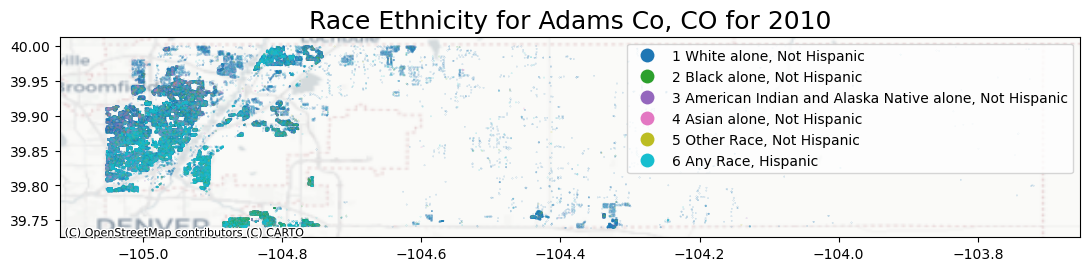

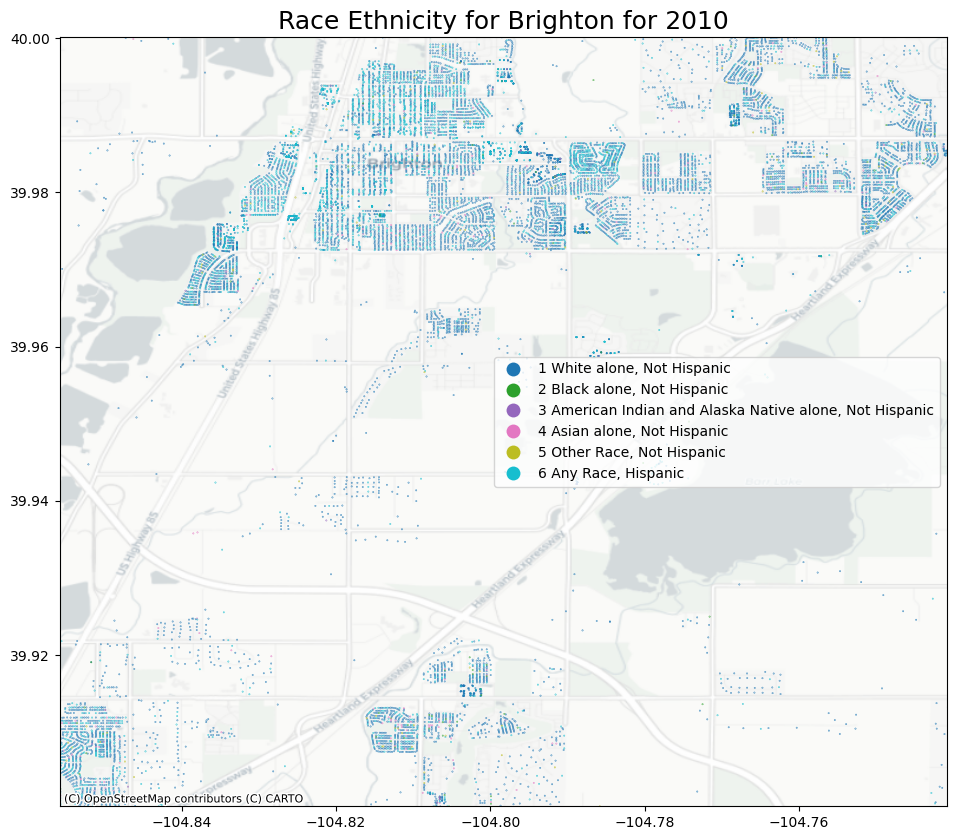

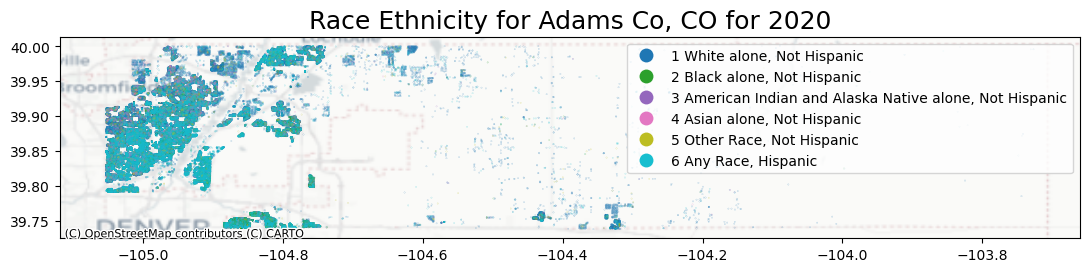

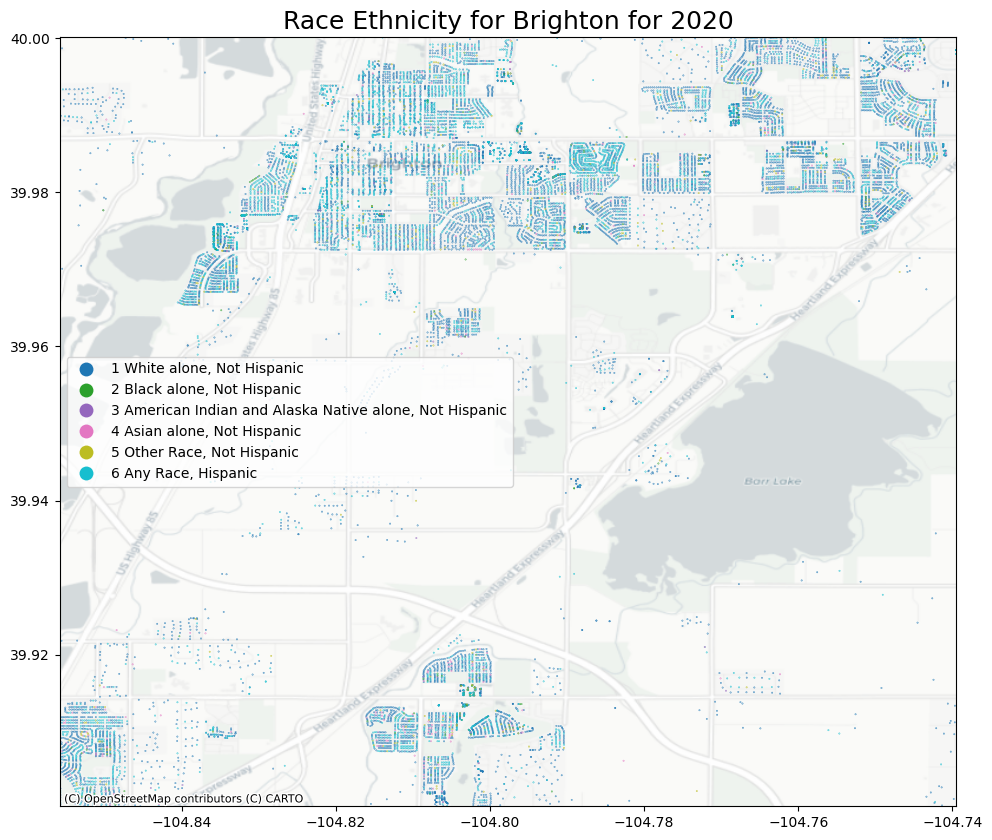

In [68]:
from pyncoda.ncoda_04b_foliummaps import *
# plot png file
from IPython.display import Image

for year in ['2010','2020']:
    # add race ethnicity to data frame for better map legends
    hua_hui_race_gdf_dict[year] = PopResultsTable.add_race_ethnicity_to_pop_df(hua_hui_gdf_dict[year])

    #mapname = 'hhincdotmap'
    mapname = f'hhracedotmap_{year}'
    # Map column
    #map_var = 'Household Income Group'
    map_var = 'Race Ethnicity'
    place = focalplace

    yr = str(year)[2:4]
    condition1 = "(hua_hui_race_gdf_dict[year].race >= 1)"
    condition2 = f"(hua_hui_race_gdf_dict[year].placeNAME{yr} == '{place}')"
    conditions = f"{condition1} & {condition2}"

    county_hua_gdf_dict[year] = hua_hui_race_gdf_dict[year].loc[eval(condition1)].copy(deep=True)
    county_hua_gdf_dict[year] = county_hua_gdf_dict[year].to_crs(epsg=4326)
    focal_place_hua_gdf_dict[year] = hua_hui_race_gdf_dict[year].loc[eval(conditions)].copy(deep=True)
    focal_place_hua_gdf_dict[year] = focal_place_hua_gdf_dict[year].to_crs(epsg=4326)

    bldg_inv_id = communities[community_id]['building_inventory']['id']
    outputfolder = 'OutputData'
    community = communities[community_id]['community_name']

    county_map = plot_dotmap_map(gdf=county_hua_gdf_dict[year],
                            mapname=mapname,
                            map_var=map_var,
                            bldg_inv_id=bldg_inv_id,
                            community=community_id,
                            place = community,
                            year = year,
                            outputfolder=outputfolder,
                            condition_id = "1",
                            basemap_source = cx.providers.CartoDB.Positron)
    
    # get xlim and ylim for focal place
    xlim = [focal_place_hua_gdf_dict[year].total_bounds[0], focal_place_hua_gdf_dict[year].total_bounds[2]]
    ylim = [focal_place_hua_gdf_dict[year].total_bounds[1], focal_place_hua_gdf_dict[year].total_bounds[3]]
    print(xlim, ylim)

    focal_place_map = plot_dotmap_map(gdf=county_hua_gdf_dict[year],
                        mapname=mapname,
                        map_var=map_var,
                        bldg_inv_id=bldg_inv_id,
                        community=community_id,
                        place = focalplace,
                        year = year,
                        outputfolder=outputfolder,
                        condition_id = "2",
                        basemap_source = cx.providers.CartoDB.Positron,
                        xlim = xlim,
                        ylim = ylim,
                        focal_gdf = focal_place_hua_gdf_dict[year])

In [ ]:
# Make an animated GIF from the PNG images
from PIL import Image

# File paths for the PNG images
image1 = 'OutputData/Adams_County_CO_NSI/06_Explore/hhracedotmap_2010_Adams_County_CO_NSI_2_NSI.png'
image2 = 'OutputData/Adams_County_CO_NSI/06_Explore/hhracedotmap_2020_Adams_County_CO_NSI_2_NSI.png'
png_files = [image1, image2]

# Open the images
images = [Image.open(png) for png in png_files]

# Save as an animated GIF
output_gif = 'OutputData/animated_map.gif'
images[0].save(
    output_gif,
    save_all=True,
    append_images=images[1:],  # Add the other images
    duration=1000,  # Duration for each frame in milliseconds
    loop=0  # Loop forever (set to 1 for a single loop)
)

## View Codebook
The Housing Unit Allocation methodology generates a codebook for the housing unit inventory.

Look in the OutputData folder to find the codebook.